# Tutorial: Simple Legal Contract Review Workflow with AgentGrid SDKs
- Author: Shridhar Kini
- To Securely Run: `jupyter notebook password` to generate onetime password for secure access
- To Run at root directory of the repo: `jupyter notebook --allow-root --port 9999 --ip=0.0.0.0` 
- To Clear Outputs: Use `jupyter nbconvert --clear-output --inplace Simple_workflow.ipynb` 

This walkthrough demonstrates how to build and orchestrate a sequential workflow of agents using the **AgentGrid SDKs** and **AgentGrid Workflow Engine**. We focus on a **Legal Contract Review Workflow**, where a contract passes through 5 specialized agents. Workflows help in binding agent flows without hardcoding data routing directly into the agent code or YAML, allowing the path of data movements to be constructed dynamically at run time.

## 1. Directory Structure
Understanding the files in this demonstration:
* **`nodes/`**: Contains the Python code for each agent (`clause_extractor_agent.py`, `risk_identifier_agent.py`, `compliance_checker_agent.py`, `negotiation_adviser_agent.py`, `legal_memo_agent.py`).
* **`spec/`**: Contains agent registration JSON specifications (`agent_clause_extractor.json`, etc.) and bash scripts for agent-level operations (registering, deploying, removing, unregistering).
* **`deploy_run/`**: Contains the `workflow_spec.json` (which defines the data flow between the agents), the Streamlit dashboard code (`streamlit_app.py`, `structure`), and the bash scripts for workflow orchestration and inference.

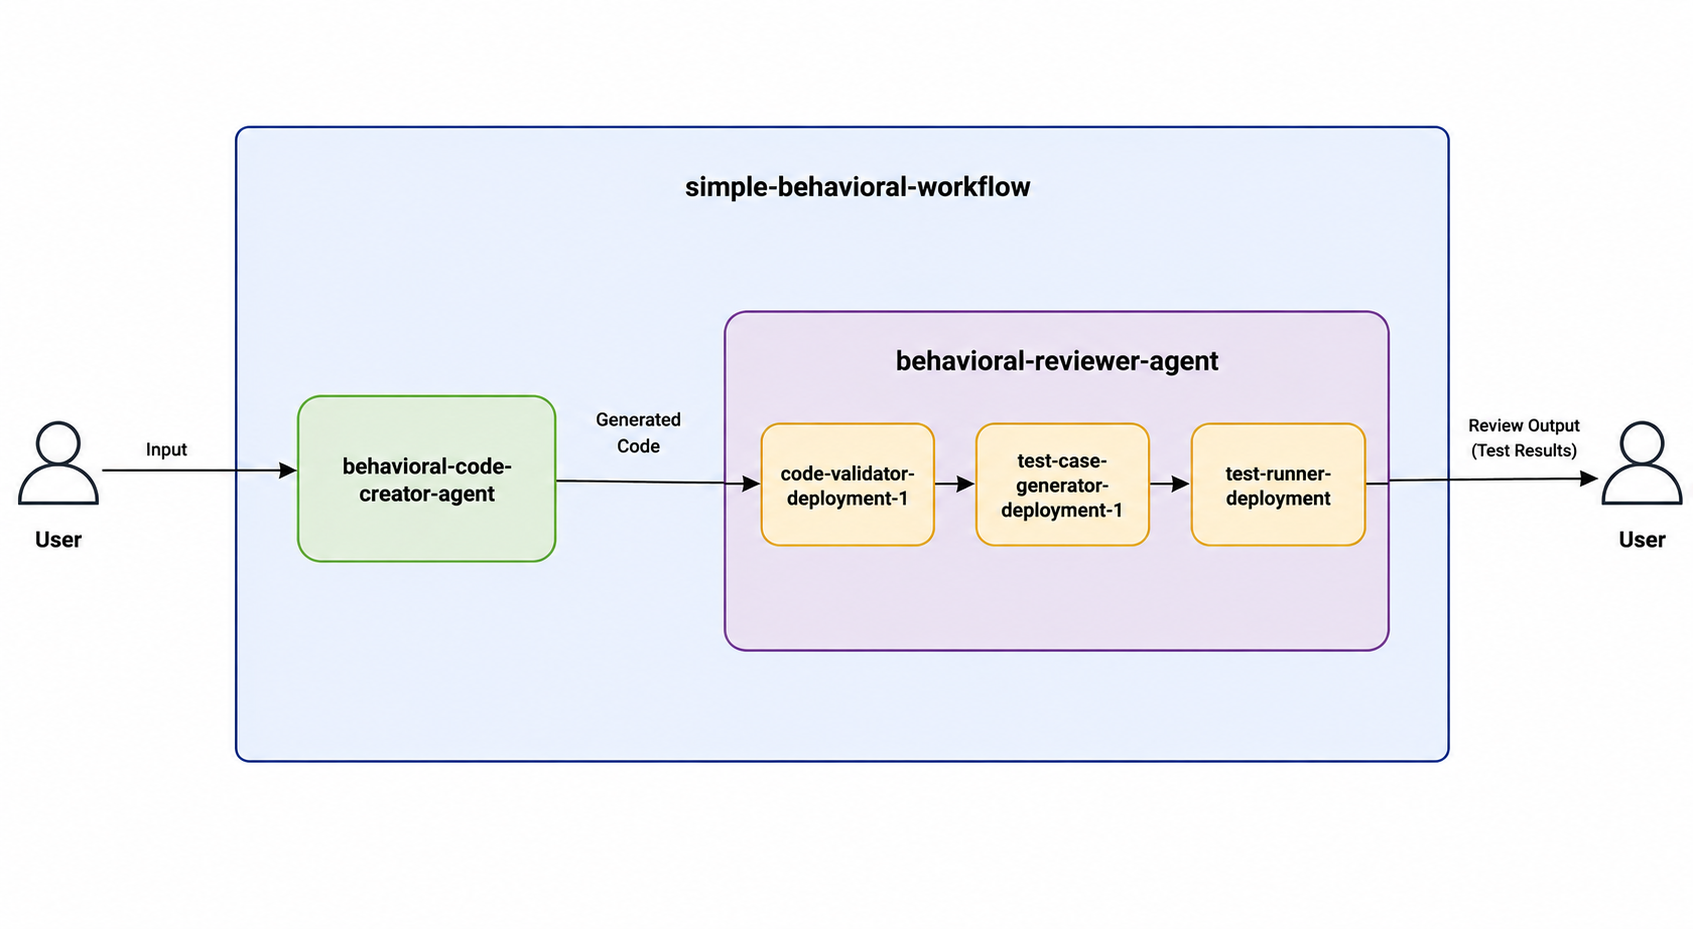

## 2. Register and Build Individual Agents
Before agents can be deployed, they must be registered to the system and packaged as Docker containers.

### Register the agents

In [ ]:
%%bash
(
  cd ../spec/
  bash register_agents.sh
)

### Build the docker images and push them to the repository

In [ ]:
%%bash
(
  cd ../../
  bash build_behavioral_workflow_and_push.bash
)

## 3. Deploy the Behavioral Functions

### 1. Zip the Functions Files

In [ ]:
%%bash
(
  cd ../graph/code_analysis/function1_validator
  bash create_zip.sh
  cd ../function2_test_gen
  bash create_zip.sh
  cd ../function3_runner
  bash create_zip.sh
)

### 2. Upload the Zipped Files

In [ ]:
%%bash
(
  cd ../graph
  bash upload.sh
)

### 3. Register Functions

In [ ]:
%%bash
(
  cd ../graph/code_analysis
  bash function1_registration_test_gen.sh
  bash function2_registration_validator.sh
  bash function3_registration__runner.sh
)

### 4. Deploy the Function

In [ ]:
%%bash
(
  cd ../graph/code_analysis
  bash function1.sh
  bash function2.sh
  bash function3.sh
)

### 5. Register the Graph

In [ ]:
%%bash
(
  cd ../graph
  bash graph.sh
)

### 6. Test the registered Graph

In [ ]:
%%bash
(
  cd ../graph
  bash call_graph.sh
)

## 4. Deploy Agents
Once the images are built and pushed, deploy the agents into the cluster so they are actively waiting for tasks.

### Deploy the agents into the cluster

In [ ]:
%%bash
(
  cd ../spec/
  bash deploy_agents.sh
)

### Verify that the agents are running

In [ ]:
!kubectl get pods -n agents

## 5. Register and Deploy the Workflow
The `workflow_spec.json` defines how the outputs of one agent map dynamically to the inputs of the next agent. We need to register this spec and deploy it.

### Register the workflow

In [ ]:
%%bash
(
  bash register_workflow.sh
)

### Deploy the workflow to establish connections
This creates a central coordinator for the workflow which acts like a Controller co-ordinating between different agents based on workflow defined. It provides API URLs for interacting with input or any other task of workflow

In [ ]:
%%bash
(
  bash deploy_workflow.sh
)

### Verify that the workflow pods are running

In [ ]:
!kubectl get pods -n workflows

## 6. Run the Workflow Demo
With everything deployed, start the Streamlit Dashboard to visualize the flow, and feed the initial payload into the first agent.

### Run the Streamlit app in the background

In [ ]:
%%bash
(
  source ../../../venv/bin/activate
  nohup bash run_streamlit_app.bash > streamlit.log 2>&1 &
  echo "Dashboard starting in background..."
)

Dashboard starting in background...


### Trigger the inference by sending a contract to the workflow inbox

In [ ]:
%%bash
(
  bash workflow_input.sh
)

## 7. Clean Up and Destroy Resources
Once the demonstration is complete, cleanly tear down the resources.

### Remove workflow connections and coordinator pods

In [ ]:
%%bash
(
  bash remove_workflow.sh
)

### Unregister the workflow entirely

In [ ]:
%%bash
(
  bash unregister_workflow.sh
)

### Remove the agent pods

In [ ]:
%%bash
(
  cd ../spec
  bash remove_agents.sh
)

### Unregister the individual agents from the AgentGrid system

In [ ]:
%%bash
(
  cd ../spec
  bash unregister_agents.sh
)

### Remove the Functions

In [ ]:
%%bash
(
  cd ../graph/code_analysis/
  bash function_remove_all.bash
)

### Unregister the Functions

In [ ]:
%%bash
(
  cd ../graph/code_analysis/
  bash function_unregister_all.bash
)

### Unregister the Graph

In [ ]:
%%bash
(
  cd ../graph
  bash graph_unregister.bash
)